In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc 

# 2.1 Sequences of Fair Coin Flips Can Be Understood as Sampling the Uniform Distribution on $[0, 1]$

$n = \sum^p_{j=1}{\frac{f_j}{2^j}}$

The Minimum would be if every result $f_j = 0$ for all $j$. Therefore $n = 0$.

In [3]:
# calculation of n for f_j =1 for all j
n = np.ones(16)
s = 0
for x  in range(len(n)):
    s = s + 1/(2**(x+1))
print('The Maximum would be if every result f_j =1. For p=16 his would be ',s)

The Maximum would be if every result f_j =1. For p=16 his would be  0.9999847412109375


For $p \rightarrow \infty$ we can use that we  have a geometric series: $n' = \sum\limits_{j=0}^{\infty}q^j =\frac{1}{1-q}$ with $q = 0.5$. We get $n' =2$. Since we start at $j=1$ we have $n = n'-\frac{1}{2^0} = 2-1 =1$ 

In [4]:


def coinflips_n(flips):
    """
    Convert flips into a decimal number via sum( f_j/2^j)
    """
    result = np.random.randint(2, size = flips)
    n_result = 0
    
    for a in range(len(result)):
        
        n_result = n_result + result[a]/2**(a+1)
    
    return n_result

# Sequences
S = [10**2,10**4, 10**6]
   

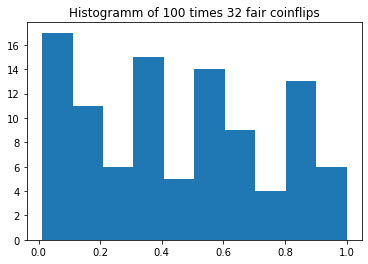

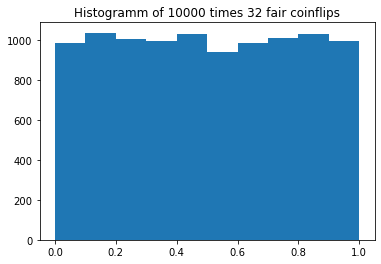

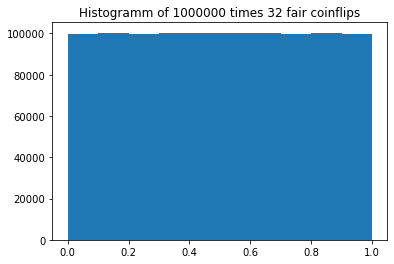

In [5]:
# result
for sequence in range(len(S)):
    
    values = np.zeros(S[sequence])
    
    for x in range(len(values)):
        
        values[x] = coinflips_n(32)
    
    plt.hist(values)
    plt.title(f"Histogramm of {S[sequence]} times 32 fair coinflips")
    plt.show()

# 2.2 Independent Coins with Different Distributions

In [128]:
def coinflips_n_bias(flips,bias):
    """
    Convert flips into a decimal number via sum( f_j/2^j)
    with P_j[tails] = 1-P_j[heads] = 1/(1+np.exp(-lambda/2**(j+1)))
    """
    n_result = np.zeros(10**6)  
    result = np.zeros(10**6)    
    
    for a in range(flips):
        # calculate current probaility
        p = 1/(1+np.exp(-bias/2**(a+2)))
        # random heads,taisl with current probaility
        result = random.choice(2, p=[p,1-p], size=(10**6)) 
        n_result = n_result + result/2**(a+1) 
                       
    return n_result


In [129]:
# different lambdas
Bias = [0,0.5,1,2]

values_0 = coinflips_n_bias(32, Bias[0])
values_0_5 = coinflips_n_bias(32, Bias[1])
values_1 = coinflips_n_bias(32, Bias[2])
values_2 = coinflips_n_bias(32, Bias[3])
        

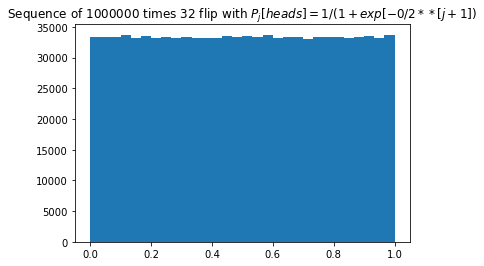

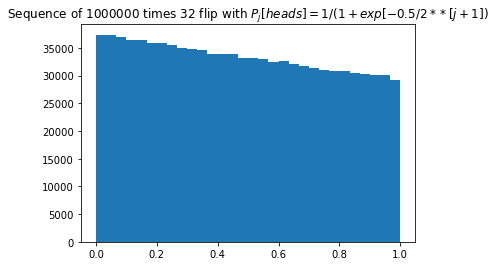

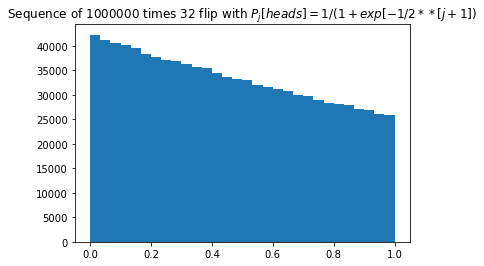

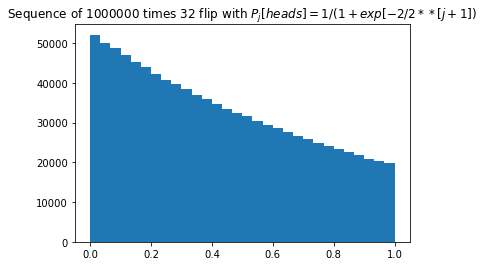

In [130]:
value_tot = [values_0,values_0_5,values_1,values_2]
for lam in range(len(Bias)):
    plt.hist(value_tot[lam], bins=30)
    plt.title(fr"Sequence of {s} times 32 flip with $P_j[heads] = 1/(1+exp[-{Bias[lam]} /2**[j+1])$")

    plt.show()

$P(x)\propto e^{-\lambda x}$. We know that this is a probability density. Therefore $\int_0^\infty P(x) =1$.

$$\int_0^\infty P(x) = N\cdot\int_0^\infty e^{-\lambda x} = N\cdot\frac{1}{\lambda}$$

The Normalization factor $N$ should be $\lambda$. 
$P(x,\lambda)=\lambda e^{-\lambda x}$

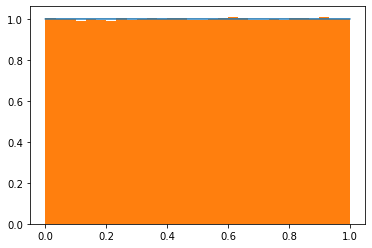

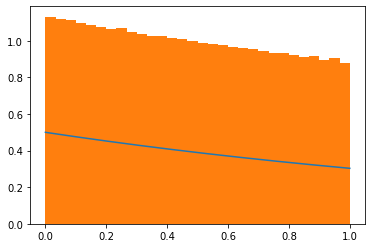

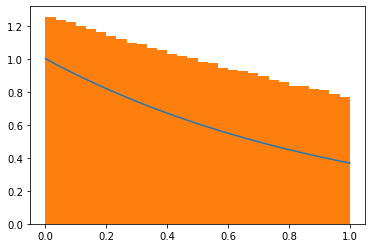

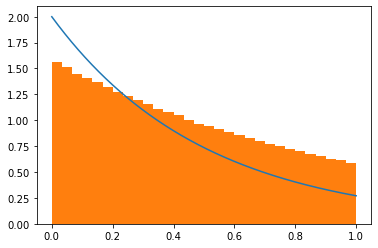

In [125]:
x = np.linspace(0,1,100000)

def P_exp(x,lam):
    return lam*np.exp(-lam*x)


for lam in range(len(Bias)):
    if lam ==0:
        plt.plot(x,P_exp(x,Bias[lam])+1) # since uniformly distributed
    else :
        plt.plot(x,P_exp(x,Bias[lam]))
    plt.hist(value_tot[lam], bins=30, density = True)
    plt.show()

# 2.3 Transforming CDF


$\text{CDF}_{\mu,\sigma}(x)=\int_0^X N_{\mu,\sigma} =\frac{1}{\sqrt{2\pi\sigma^2}}\int_{-\infty}^X e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

Substitute $t =\frac{x-\mu}{\sigma}$ we get 

$$ \text{CDF}_{\mu,\sigma}(t) =\sigma \cdot \frac{1}{\sqrt{2\pi\sigma^2}}\int_{-\infty}^{(X-\mu)/\sigma} e^{-\frac{t^2}{2}} = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{(X-\mu)/\sigma} e^{-\frac{t^2}{2}} $$

This is $\text{CDF}_{\mu=0,\sigma=1}$ for $[x \leq{(X-\mu)/\sigma}]$. 
The CDF is given by $\text{CDF}_{\mu=0,\sigma=1}(t) = \frac{1}{2}\left(1+ \text{erf}(\frac{t}{\sqrt{2}})\right)$

Now we resusbstitute and get $\text{CDF}_{\mu,\sigma}(t)  = \frac{1}{2}\left(1+ \text{erf}(\frac{x-\mu}{\sqrt{2\sigma^2}})\right)$


# 2.4 Inverse Transform Sampling

In [131]:
def CDF_logisic_squared(x):
    return ((1+np.tanh(x/6))/2)**2
            
x = np.linspace(-20,30,100000)
            


In [133]:
# calculate CDF^-1

uniform_samples = np.random.uniform(low=0, high=1, size=(10**5))
preimage = np.fromiter(
    (sc.optimize.fsolve(
        lambda x: CDF_logisic_squared(x)-u,
        (0,)
    )[0] for u in uniform_samples),
    dtype=float
    )


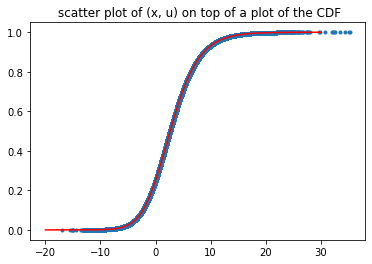

In [134]:
plt.title(" scatter plot of (x, u) on top of a plot of the CDF")
plt.scatter(preimage,uniform_samples, marker ='.', label = "(x,u)")
plt.plot(x,CDF_logisic_squared(x), color ='red', label = "CDF")
plt.show()

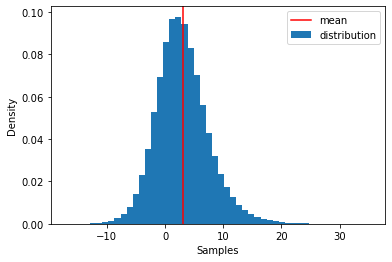

In [138]:
fig, ax = plt.subplots()
ax.hist(preimage, bins=50, density=True , label = "distribution")
ax.axvline(preimage.mean(), color='red', label = "mean")
ax.set_ylabel('Density')
ax.set_xlabel('Samples')
ax.legend()
plt.show()

$P(X)=\frac{d}{dx}\left(\frac{1+\tanh(\frac{x}{6})}{2}\right)^2 = \frac{1}{12}(\tanh(\frac{x}{6})+1)/\cosh^2(\frac{x}{6})$

In [136]:
def p_logistic(x):
    return 1/12 *(np.tanh(x/6)+1)/(np.cosh(x/6))**2

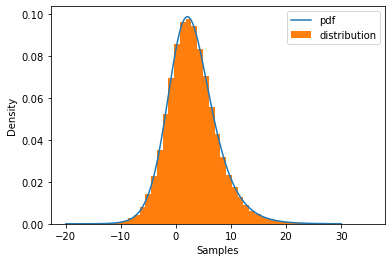

In [141]:

fig, ax = plt.subplots()
ax.plot(x,p_logistic(x), label = "pdf")
ax.hist(preimage, bins=50, density=True , label = "distribution")
ax.set_ylabel('Density')
ax.set_xlabel('Samples')
ax.legend()
plt.show()